# CeNN P-Delta2 — Beat-the-Transformer Colab

Tests a curvature-aware **Preconditioned Delta2** layer against frozen SmolLM2 attention. The balanced profile pre-registers seven scenarios: current Delta2, pure P-Delta2 at 64/96/128 features, P-Delta2 + exact local windows, and a Delta2-window control. Selection is validation-only; test scoring is locked afterward.

Success is either a **strict held-out NLL win** (paired 95% bootstrap interval below zero) or **memory-efficient parity** (inside ±0.02 nats with <50% of FP16 Transformer KV state). It also tests 256/512/1024-token contexts.

Research basis: [Preconditioned DeltaNet](https://arxiv.org/abs/2604.21100), [Gated DeltaNet-2](https://arxiv.org/abs/2605.22791), and [Kimi Linear](https://arxiv.org/abs/2510.26692). This is an independent research adaptation, not a reproduction of fused paper kernels.


In [1]:
import pathlib, subprocess, sys
REF='codex/pdelta2-beat-transformer-20260914'
REPO=pathlib.Path('/content/TinyCeNN-LM')
if REPO.exists():
    subprocess.run(['git','-C',str(REPO),'fetch','origin'],check=True)
else:
    subprocess.run(['git','clone','https://github.com/vtavakkoli/TinyCeNN-LM.git',str(REPO)],check=True)
subprocess.run(['git','-C',str(REPO),'checkout','-B','pdelta2-run',f'origin/{REF}'],check=True)
subprocess.run([sys.executable,'-m','pip','install','-q','-e',str(REPO),'transformers==4.57.6','datasets>=3,<5','pandas','matplotlib'],check=True)
print('Commit:',subprocess.check_output(['git','-C',str(REPO),'rev-parse','--short','HEAD'],text=True).strip())


Commit: 73a334e


In [2]:
PROFILE='balanced'  # quick | balanced | strong
LAYER=18
TRAIN_CONTEXT=256
TEST_CONTEXTS='256,512,1024'
OUTDIR=REPO/'result'/'pdelta2-beat-transformer-colab'
cmd=[sys.executable,'-m','scripts.benchmark_pdelta2_beat_transformer','--profile',PROFILE,'--layer',str(LAYER),'--train-context',str(TRAIN_CONTEXT),'--test-contexts',TEST_CONTEXTS,'--output-dir',str(OUTDIR)]
print(' '.join(cmd))
subprocess.run(cmd,check=True,cwd=REPO)


/usr/bin/python3 -m scripts.benchmark_pdelta2_beat_transformer --profile balanced --layer 18 --train-context 256 --test-contexts 256,512,1024 --output-dir /content/TinyCeNN-LM/result/pdelta2-beat-transformer-colab


CompletedProcess(args=['/usr/bin/python3', '-m', 'scripts.benchmark_pdelta2_beat_transformer', '--profile', 'balanced', '--layer', '18', '--train-context', '256', '--test-contexts', '256,512,1024', '--output-dir', '/content/TinyCeNN-LM/result/pdelta2-beat-transformer-colab'], returncode=0)

Validation-selected winner: pdelta2_w64_f128


,name,kind,feature_dim,window,validation_nll,validation_ppl,output_nmse,output_cosine,trainable_parameters
0,pdelta2_w64_f128,pdelta2,128,64,2.762340,15.836860,0.228821,0.742476,162072
1,pdelta2_f128,pdelta2,128,0,2.764715,15.874513,0.357248,0.705575,161487
2,pdelta2_f64,pdelta2,64,0,2.765709,15.890295,0.351831,0.745360,86991
3,pdelta2_f96,pdelta2,96,0,2.765756,15.891045,0.357252,0.711070,124239
4,delta2_f64,delta2,64,0,2.767323,15.915969,0.367800,0.678602,86601
5,pdelta2_w32_f96,pdelta2,96,32,2.767393,15.917078,0.267074,0.720980,124824
6,delta2_w32_f64,delta2,64,32,2.773704,16.017848,0.309345,0.704859,87186


,candidate,context,candidate_nll,transformer_nll,delta_nll,ci95_low,ci95_high,candidate_ppl,transformer_ppl,ppl_ratio,state_bytes,transformer_kv_bytes_fp16,state_vs_transformer_fp16,verdict,selected_on_validation
0,pdelta2_w32_f96,256,2.902235,2.892385,0.009849,0.005896,0.014034,18.214802,18.036279,1.009898,122496,196608,0.623047,within_declared_nll_margin,False
1,pdelta2_w64_f128,256,2.902470,2.892385,0.010085,0.006218,0.013994,18.219095,18.036279,1.010136,196608,196608,1.000000,within_declared_nll_margin,True
2,pdelta2_f64,256,2.905317,2.892385,0.012932,0.007703,0.018351,18.271031,18.036279,1.013016,49920,196608,0.253906,memory_efficient_parity,False
3,pdelta2_f128,256,2.905339,2.892385,0.012954,0.007348,0.018789,18.271445,18.036279,1.013039,99840,196608,0.507812,within_declared_nll_margin,False
4,delta2_f64,256,2.905798,2.892385,0.013413,0.008409,0.018911,18.279821,18.036279,1.013503,49152,196608,0.250000,memory_efficient_parity,False
5,delta2_w32_f64,256,2.905822,2.892385,0.013437,0.008660,0.018513,18.280270,18.036279,1.013528,96768,196608,0.492188,memory_efficient_parity,False
6,pdelta2_f96,256,2.905891,2.892385,0.013505,0.008206,0.019119,18.281517,18.036279,1.013597,74880,196608,0.380859,memory_efficient_parity,False
7,pdelta2_w64_f128,512,2.784972,2.773690,0.011282,0.007592,0.014915,16.199362,16.017626,1.011346,196608,393216,0.500000,within_declared_nll_margin,True
8,delta2_f64,512,2.791458,2.773690,0.017769,0.013178,0.022617,16.304781,16.017626,1.017927,49152,393216,0.125000,inconclusive,False
9,pdelta2_w64_f128,1024,2.726514,2.709607,0.016907,0.013491,0.020463,15.279523,15.023365,1.017051,196608,786432,0.250000,inconclusive,True


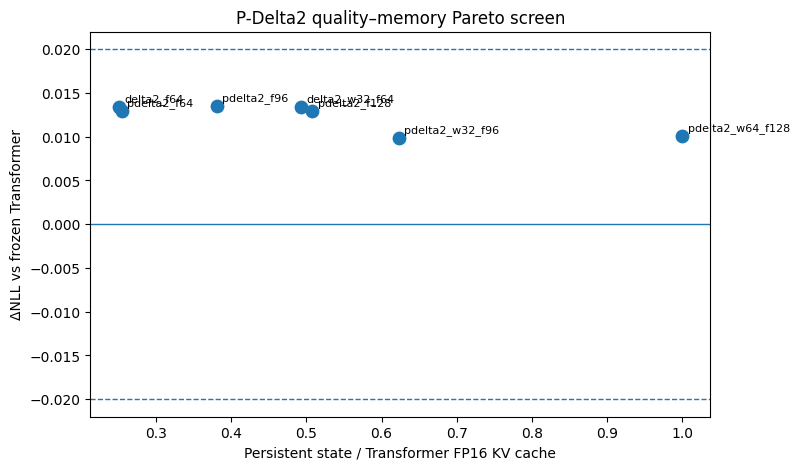

In [3]:
import json, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
val=pd.read_csv(OUTDIR/'validation_summary.csv')
test=pd.read_csv(OUTDIR/'test_summary.csv')
report=json.loads((OUTDIR/'pdelta2_report.json').read_text())
print('Validation-selected winner:',report['winner_selected_on_validation'])
display(val.round(6)); display(test.round(6))
r=test[test.context==TRAIN_CONTEXT]
fig,ax=plt.subplots(figsize=(8,5)); ax.scatter(r.state_vs_transformer_fp16,r.delta_nll,s=80)
for _,x in r.iterrows(): ax.annotate(x.candidate,(x.state_vs_transformer_fp16,x.delta_nll),xytext=(4,4),textcoords='offset points',fontsize=8)
ax.axhline(0,linewidth=1); ax.axhline(.02,linewidth=1,linestyle='--'); ax.axhline(-.02,linewidth=1,linestyle='--')
ax.set_xlabel('Persistent state / Transformer FP16 KV cache'); ax.set_ylabel('ΔNLL vs frozen Transformer'); ax.set_title('P-Delta2 quality–memory Pareto screen'); plt.show()


## Interpretation

`strict_quality_win` is the strongest signal. `memory_efficient_parity` is also important because P-Delta2 state is bounded while Transformer KV state grows with context. If this wins, the next rigorous step is multi-layer replacement plus a matched Transformer adaptation control. Speed is not the target of this reference PyTorch implementation; fused Triton/CUDA work should follow only after quality succeeds.
